# Exploratory Data Analysis: FIFA Player Rating Pipeline

This notebook records the data checks used to design the cleaning and feature-engineering steps in the Kedro project. It uses the raw player-attribute sample and the shared utility functions from `src/mlops_player_rating/` so that the exploratory checks stay close to the pipeline implementation.

## 1. Load and normalize the raw table

Input: `data/01_raw/player_attributes.csv`, a deterministic 6,000-row extract from the European Soccer Database player-attribute snapshots. Column normalization is applied before profiling so the notebook uses the same names as the project pipelines.


In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from mlops_player_rating import utils

raw = pd.read_csv('../data/01_raw/player_attributes.csv')
df = utils.normalize_columns(raw)
print(df.shape)
df.head()

(6000, 46)


,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,player_name,birthday,height,weight
0,73022,197117,188054,2013-09-27 00:00:00,74.0,81.0,left,medium,low,67.0,...,20.0,10.0,5.0,7.0,13.0,15.0,Ioannis Fetfatzidis,1990-12-21 00:00:00,165.10,141
1,5871,204166,156534,2013-05-24 00:00:00,67.0,72.0,right,high,low,63.0,...,48.0,6.0,6.0,8.0,13.0,13.0,Aleksandar Tonev,1990-02-03 00:00:00,177.80,152
2,93693,178132,29257,2016-03-24 00:00:00,70.0,70.0,right,high,medium,68.0,...,25.0,14.0,8.0,16.0,16.0,10.0,Karim Matmour,1985-06-25 00:00:00,180.34,165
3,90651,194519,190452,2015-10-16 00:00:00,71.0,75.0,left,medium,medium,69.0,...,72.0,13.0,12.0,13.0,11.0,16.0,Juan Rafael Fuentes,1990-01-05 00:00:00,177.80,154
4,183895,105454,99031,2007-02-22 00:00:00,69.0,78.0,left,high,low,66.0,...,12.0,1.0,20.0,65.0,20.0,20.0,Zoran Tosic,1987-04-28 00:00:00,170.18,157


## 2. Target distribution

`overall_rating` ranges from 42 to 90 in this sample, with a mean close to 68 and no heavy right tail. The target is already on an interpretable 0-100 rating scale, so the model can predict rating points directly instead of using a transformed target.


count    5970.00
mean       68.48
std         7.01
min        42.00
25%        64.00
50%        69.00
75%        73.00
max        90.00
Name: overall_rating, dtype: float64


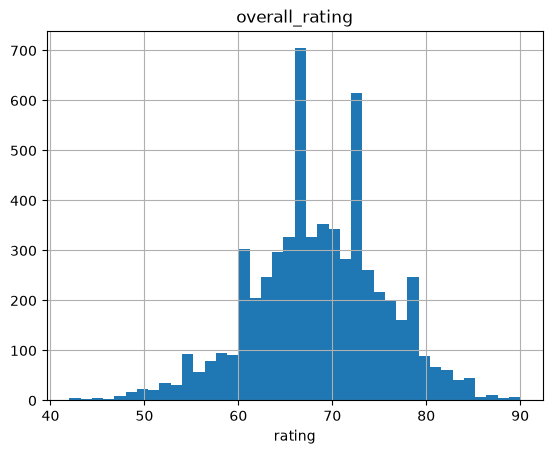

In [2]:
print(df['overall_rating'].describe().round(2))
df['overall_rating'].hist(bins=40); plt.title('overall_rating'); plt.xlabel('rating'); plt.show()

## 3. Data quality checks used by the pipeline

The next cell profiles the raw sample and builds the cleaning summary from the observed values. The implementation choices match the cleaning and feature-engineering code used by the Kedro pipeline.


In [3]:
# Dirty work-rate categories and missingness summary
work_rate_cols = ['attacking_work_rate', 'defensive_work_rate']
valid_work_rates = {'low', 'medium', 'high'}

invalid_work_rates = {}
for col in work_rate_cols:
    values = set(df[col].dropna().astype(str).str.lower().unique())
    invalid_work_rates[col] = sorted(values - valid_work_rates)

null_target_rows = int(df['overall_rating'].isna().sum())
attribute_nulls = df[utils.SKILL_COLUMNS].isna().sum().sort_values(ascending=False)
attribute_cols_with_nulls = int((attribute_nulls > 0).sum())
max_attribute_nulls = int(attribute_nulls.max())
potential_corr = round(df[['potential', 'overall_rating']].corr().iloc[0, 1], 3)

print('attacking_work_rate raw values:')
print(df['attacking_work_rate'].value_counts(dropna=False).head(12))
print()
print('null target rows:', null_target_rows)
print()
print('top-null attribute columns:')
print(attribute_nulls.head(8))

pd.DataFrame([
    {
        'check': 'missing target',
        'observed': f'{null_target_rows} rows',
        'pipeline handling': 'drop before model training and evaluation',
    },
    {
        'check': 'work-rate values',
        'observed': '; '.join(f'{col}: {vals}' for col, vals in invalid_work_rates.items() if vals),
        'pipeline handling': 'map valid labels; replace invalid or missing labels with medium',
    },
    {
        'check': 'attribute missingness',
        'observed': f'{attribute_cols_with_nulls} skill columns with nulls; max {max_attribute_nulls} rows in one column',
        'pipeline handling': 'use saved medians fitted in the cleaning step for training and inference',
    },
    {
        'check': 'potential field',
        'observed': f'corr with overall_rating = {potential_corr}',
        'pipeline handling': 'exclude from model features',
    },
])


attacking_work_rate raw values:
attacking_work_rate
medium    4051
high      1441
low        272
NaN        218
norm         7
y            5
le           3
stoc         3
Name: count, dtype: int64

null target rows: 30

top-null attribute columns:
volleys           93
jumping           93
curve             93
balance           93
agility           93
sliding_tackle    93
vision            93
crossing          30
dtype: int64


,check,observed,pipeline handling
0,missing target,30 rows,drop before model training and evaluation
1,work-rate values,"attacking_work_rate: ['le', 'norm', 'stoc', 'y...",map valid labels; replace invalid or missing l...
2,attribute missingness,33 skill columns with nulls; max 93 rows in on...,use saved medians fitted in the cleaning step ...
3,potential field,corr with overall_rating = 0.764,exclude from model features


## 4. Feature signal and engineered columns

The correlation table keeps `potential` visible only to document the exclusion decision. Among retained inputs, `reactions`, passing, ball-control, shooting, and vision features carry the strongest individual linear signal.

The feature-engineering step adds `age`, `bmi`, an `is_goalkeeper` flag, and grouped attribute means such as `attacking_mean`, `defending_mean`, and `goalkeeping_mean`. These columns reduce repeated logic across the model, batch prediction, and serving paths.


In [4]:
num = df.select_dtypes('number')
corr = num.corr()['overall_rating'].drop('overall_rating').sort_values(ascending=False)
print('Top correlations with overall_rating:')
print(corr.head(10).round(3))
print()
print('potential vs overall_rating corr:', round(df[['potential','overall_rating']].corr().iloc[0,1], 3))

# Engineered features (age, bmi, attribute-group means, is_goalkeeper)
eng = utils.engineer_features(utils.apply_value_semantics(df))
print()
print('engineered age range:', round(eng['age'].min(),1), '-', round(eng['age'].max(),1))
print('goalkeepers flagged:', int(eng['is_goalkeeper'].sum()), 'of', len(eng))
eng[['age','bmi','attacking_mean','defending_mean','goalkeeping_mean']].describe().round(1)


Top correlations with overall_rating:
reactions        0.765
potential        0.764
short_passing    0.451
ball_control     0.440
long_passing     0.427
shot_power       0.416
vision           0.415
long_shots       0.392
penalties        0.369
volleys          0.351
Name: overall_rating, dtype: float64

potential vs overall_rating corr: 0.764

engineered age range: 14.0 - 42.9
goalkeepers flagged: 465 of 6000


,age,bmi,attacking_mean,defending_mean,goalkeeping_mean
count,6000.0,6000.0,5970.0,5970.0,5970.0
mean,25.8,23.1,54.8,48.6,16.7
std,4.7,1.3,13.6,20.9,16.0
min,14.0,18.4,5.8,7.0,1.0
25%,22.3,22.2,48.8,27.3,9.4
50%,25.5,23.1,57.2,53.3,10.6
75%,29.0,23.9,63.8,67.0,12.6
max,42.9,30.9,84.4,91.0,86.8
